<a href="https://colab.research.google.com/github/Elwing-Chou/ximen_ai_20260706/blob/main/ximen_20260720.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import urllib.request as req
url = "https://github.com/Elwing-Chou/ximen_ai_20260706/raw/refs/heads/main/titanic/train.csv"
req.urlretrieve(url, "train.csv")
url = "https://github.com/Elwing-Chou/ximen_ai_20260706/raw/refs/heads/main/titanic/test.csv"
req.urlretrieve(url, "test.csv")

('test.csv', <http.client.HTTPMessage at 0x797d467fcce0>)

In [2]:
import pandas as pd
train_df = pd.read_csv("train.csv", encoding="utf-8")
test_df = pd.read_csv("test.csv", encoding="utf-8")

In [3]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


1. 過濾: 保留需要的
2. 轉換: old val -> new val

In [4]:
demo = test_df.head(3)
# 過濾: 準備跟你的資料筆數依樣多True/False的list裡
fil = [True, False, True]
# 準備好帶入[]
demo[fil]
# 實際上: 你會用操作轉成True, False
# pandas資料型態: DataFrame(表格) Series(1D清單)
# and(&) or(|)
fil_1 = demo["Age"] < 35
fil_2 = demo["Age"] > 60
fil = fil_1 | fil_2
demo[fil]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [5]:
def func(x):
    if x == "male":
        return 0
    elif x == "female":
        return 1
    else:
        return -1
# Series apply: 一格轉一格
demo["Sex"].apply(func)

,Sex
0,0
1,1
2,0


In [6]:
# 我懶得分開做處理, 處理x的時候我通常會把我所有資料合併一起做
total_df = pd.concat([train_df, test_df])
total_df = total_df.drop(["PassengerId", "Survived"], axis=1)
total_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
# Step 0. 資料預處理(pre-processing)
def func(n):
    if pd.isna(n):
        return n
    else:
        return n.split(",")[-1].split(".")[0].strip()

total_df["Name"] = total_df["Name"].apply(func)
total_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,Mrs,female,35.0,1,0,113803,53.1000,C123,S
4,3,Mr,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,Mr,male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,Dona,female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,Mr,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,Mr,male,NaN,0,0,359309,8.0500,NaN,S


In [8]:
# unique()/value_counts()
total_df["Name"].value_counts()

,count
Name,
Mr,757
Miss,260
Mrs,197
Master,61
Rev,8
Dr,8
Col,4
Major,2
Mlle,2


In [9]:
dic = total_df["Ticket"].value_counts()
def func(n):
    if pd.isna(n):
        return n
    else:
        return dic[n]
total_df["Ticket"] = total_df["Ticket"].apply(func)

In [10]:
total_df["Cabin"].value_counts()
def func(n):
    if pd.isna(n):
        return n
    else:
        return n[0]
total_df["Cabin"] = total_df["Cabin"].apply(func)

In [11]:
total_df["Cabin"].value_counts()

,count
Cabin,
C,94
B,65
D,46
E,41
A,22
F,21
G,5
T,1


In [12]:
total_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,Mr,male,22.0,1,0,1,7.2500,NaN,S
1,1,Mrs,female,38.0,1,0,2,71.2833,C,C
2,3,Miss,female,26.0,0,0,1,7.9250,NaN,S
3,1,Mrs,female,35.0,1,0,2,53.1000,C,S
4,3,Mr,male,35.0,0,0,1,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,Mr,male,NaN,0,0,1,8.0500,NaN,S
414,1,Dona,female,39.0,0,0,3,108.9000,C,C
415,3,Mr,male,38.5,0,0,1,7.2500,NaN,S
416,3,Mr,male,NaN,0,0,1,8.0500,NaN,S


In [13]:
# 資料預處理
# 1. 補缺失值: 補最可能的
# 2. One-Hot
# x 劃分兩種
# 1. 類別型(只有數種): Pclass, Name, Sex, Cabin, Embarked
# 2. 數值型(數字): Age, SibSp, Parch, Ticket, Fare
# 1. 類別最可能的值: 最常出現的
# 2. 數值: 中位數
# !!! 如果Pclass有缺, 該補最常出現(類別)
total_df.isna().sum()

,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014
Embarked,2


In [14]:
# 如果你要補最常出現
most = total_df["Embarked"].value_counts().idxmax()
total_df["Embarked"] = total_df["Embarked"].fillna(most)
total_df.isna().sum()

,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014
Embarked,0


In [15]:
# 列出數字類型的欄位
col_nums_fil = total_df.dtypes != "object"
col_nums = total_df.columns[col_nums_fil].drop("Pclass")
# 補中位數
med = total_df[col_nums].median()
total_df[col_nums] = total_df[col_nums].fillna(med)
total_df.isna().sum()

,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,1014
Embarked,0


In [16]:
total_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,Mr,male,22.0,1,0,1,7.2500,NaN,S
1,1,Mrs,female,38.0,1,0,2,71.2833,C,C
2,3,Miss,female,26.0,0,0,1,7.9250,NaN,S
3,1,Mrs,female,35.0,1,0,2,53.1000,C,S
4,3,Mr,male,35.0,0,0,1,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,Mr,male,28.0,0,0,1,8.0500,NaN,S
414,1,Dona,female,39.0,0,0,3,108.9000,C,C
415,3,Mr,male,38.5,0,0,1,7.2500,NaN,S
416,3,Mr,male,28.0,0,0,1,8.0500,NaN,S


In [17]:
# One-Hot: 把類別->多個是非題
# 100%做
# Q1: 變成太多欄位 ->  回頭檢查資料處理
# Q2: 唯一可以不做的時候 -> 二值型類別(e.g. Sex) -> 決策樹相關無腦one-hot也沒差
# Q3: Pclass做不做? 可作可不做 -> 誰比較好(一般情況我可能隨便, 但這裡我試過, one-hot的上限會比較高一點)
# Q4: 其實你不用去掉, 如果你真的去掉(考慮美觀/使用者體驗的問題)
# Q5: One-Hot的另外好處->補類別缺失值(全部填0)

# 如果你真想丟掉
fil = total_df["Name"].value_counts() > 20
reserved = total_df["Name"].value_counts().index[fil]

def func(n):
    if n in reserved:
        return n
    else:
        return None

total_df["Name"] = total_df["Name"].apply(func)

In [18]:
# show more col
pd.set_option('display.max_columns', 50)
total_df = pd.get_dummies(total_df)
total_df = pd.get_dummies(total_df, columns=["Pclass"])
total_df

,Age,SibSp,Parch,Ticket,Fare,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Sex_female,Sex_male,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,22.0,1,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,38.0,1,0,2,71.2833,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,26.0,0,0,1,7.9250,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,35.0,1,0,2,53.1000,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False
4,35.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
414,39.0,0,0,3,108.9000,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
415,38.5,0,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
416,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True


In [19]:
# 無腦: 1. 先補中位 2. One-Hot
# Extra Step. 利用欄位做出有意義的欄位
total_df["Family"] = total_df["SibSp"] + total_df["Parch"]
total_df

,Age,SibSp,Parch,Ticket,Fare,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Sex_female,Sex_male,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Family
0,22.0,1,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,1
1,38.0,1,0,2,71.2833,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,1
2,26.0,0,0,1,7.9250,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
3,35.0,1,0,2,53.1000,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,1
4,35.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
414,39.0,0,0,3,108.9000,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,0
415,38.5,0,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
416,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0


In [20]:
# pandas操作
# 取列:
# .loc: 根據列標籤取列
# .iloc: 根據真正的第幾列取列
# list[開始:結束]
x = total_df.iloc[:len(train_df)]
y = train_df["Survived"]
x_exam = total_df.iloc[len(train_df):]
x_exam

,Age,SibSp,Parch,Ticket,Fare,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Sex_female,Sex_male,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Family
0,34.5,0,0,1,7.8292,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,0
1,47.0,1,0,1,7.0000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,1
2,62.0,0,0,1,9.6875,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,0
3,27.0,0,0,1,8.6625,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
4,22.0,1,1,2,12.2875,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
414,39.0,0,0,3,108.9000,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,0
415,38.5,0,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
416,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0


In [21]:
# 畫圖(看整體: 看這個問題是否真的可被解決)
# 降維: 25cols -> 2cols
# SNE: 高維空間倆兩點的距離想辦法複製到低維空間
# tSNE: 刻意做出距離感, 把近的拉近, 把遠的拉遠
from sklearn.manifold import TSNE
tsne = TSNE()
x_tsne = tsne.fit_transform(x)
pd.DataFrame(x_tsne)

,0,1
0,-21.778639,-17.945801
1,40.779438,0.275743
2,-28.759666,-7.203015
3,32.760254,-1.129489
4,-15.040663,17.720327
...,...,...
886,-11.251827,3.086350
887,9.563035,-8.913439
888,6.265306,-0.650694
889,12.316655,-4.658920


<Axes: >

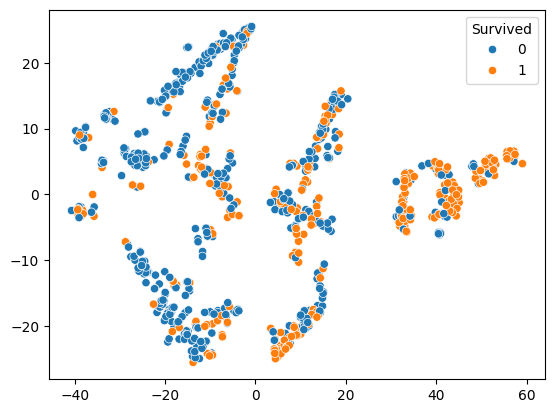

In [22]:
# numpy操作的精隨: 像是list依樣, 取單個/取一段, 但是每一個軸你都要做
# 如果是三圍  array[:, :, :]
import matplotlib.pyplot as plt
# 通常會用matplotlib的進階函示庫
import seaborn as sns

axis1 = x_tsne[:, 0]
axis2 = x_tsne[:, 1]
sns.scatterplot(x=axis1, y=axis2, hue=y)

In [23]:
# 來建立模型
# train_test 隨機80 20
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=4)
# scoring: f1 score cv: 切幾分 n_jobs:-1平行化最滿
scores = cross_val_score(clf, x, y, cv=10)
score = np.average(scores)
print(max(scores), min(scores), np.std(scores))
print("CV分數:", score)

0.8764044943820225 0.7640449438202247 0.0372450396035941
CV分數: 0.8282896379525594


In [24]:
# 如果你有很多參數要調, GridSearchCV
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
params = {
    "max_depth":range(2, 10)
}
search = GridSearchCV(clf, params, cv=10)
search.fit(x, y)
print("best score:", search.best_score_)
print("best params:", search.best_params_)

best score: 0.8282896379525594
best params: {'max_depth': 4}


In [25]:
clf = DecisionTreeClassifier(max_depth=4)
clf.fit(x, y)
ans = clf.predict(x_exam)
ans_df = pd.DataFrame({
    "PassengerId":test_df["PassengerId"],
    "Survived":ans
})
ans_df.to_csv("DT.csv", encoding="utf-8", index=False)
ans_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [26]:
# 如果你有很多參數要調, GridSearchCV
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
params = {
    "max_depth":range(5, 7),
    "n_estimators":range(51, 80, 2)
}
search = GridSearchCV(clf, params, cv=10, n_jobs=-1)
search.fit(x, y)
print("best score:", search.best_score_)
print("best params:", search.best_params_)

best score: 0.8372659176029963
best params: {'max_depth': 6, 'n_estimators': 55}


In [27]:
clf = RandomForestClassifier(max_depth=6, n_estimators=61)
clf.fit(x, y)
ans = clf.predict(x_exam)
ans_df = pd.DataFrame({
    "PassengerId":test_df["PassengerId"],
    "Survived":ans
})
ans_df.to_csv("RF.csv", encoding="utf-8", index=False)
ans_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [28]:
pd.DataFrame({
    "name":x.columns,
    "imp":clf.feature_importances_
}).sort_values("imp", ascending=False)

,name,imp
7,Name_Mr,0.156584
9,Sex_female,0.138631
10,Sex_male,0.129981
4,Fare,0.110646
24,Pclass_3,0.071316
3,Ticket,0.060853
0,Age,0.054218
6,Name_Miss,0.046008
8,Name_Mrs,0.042891
25,Family,0.040513


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# fit: 只對訓練資料做一次(找出那行的最小/最大)
scaler.fit(total_df)
# 接下來都是transform
total_df_scaled = pd.DataFrame(scaler.transform(total_df),
                               columns=total_df.columns)
total_df_scaled

In [ ]:
x_scaled = total_df_scaled.iloc[:len(train_df)]
x_exam_scaled = total_df_scaled.iloc[len(train_df):]
x_exam_scaled

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
params = {
    "n_neighbors":range(2, 30)
}
search = GridSearchCV(clf, params, cv=10, n_jobs=-1)
search.fit(x_scaled, y)
print("best score:", search.best_score_)
print("best params:", search.best_params_)

best score: 0.832796504369538
best params: {'n_neighbors': 7}


In [38]:
# 我其實是過了, 能在那個考試表現最好的參數是11
clf = KNeighborsClassifier(n_neighbors=11)
clf.fit(x_scaled, y)
ans = clf.predict(x_exam_scaled)
ans_df = pd.DataFrame({
    "PassengerId":test_df["PassengerId"],
    "Survived":ans
})
ans_df.to_csv("knn.csv", encoding="utf-8", index=False)
ans_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


<Axes: xlabel='Sex', ylabel='count'>

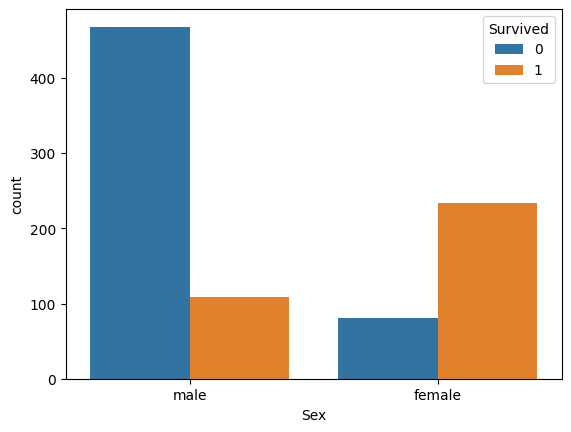

In [43]:
#
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=train_df["Sex"], hue=train_df["Survived"])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '(-0.512, 51.233]'),
  Text(1, 0, '(51.233, 102.466]'),
  Text(2, 0, '(102.466, 153.699]'),
  Text(3, 0, '(153.699, 204.932]'),
  Text(4, 0, '(204.932, 256.165]'),
  Text(5, 0, '(256.165, 307.398]'),
  Text(6, 0, '(307.398, 358.63]'),
  Text(7, 0, '(358.63, 409.863]'),
  Text(8, 0, '(409.863, 461.096]'),
  Text(9, 0, '(461.096, 512.329]')])

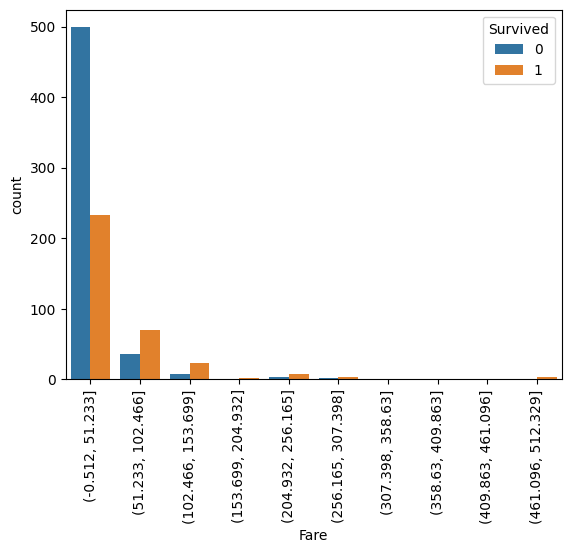

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=[20, 10])
x_cut = pd.cut(train_df["Fare"], bins=10)
sns.countplot(x=x_cut, hue=train_df["Survived"])
# legend: 圖例 axis: 軸 ticks: 刻度
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '10')])

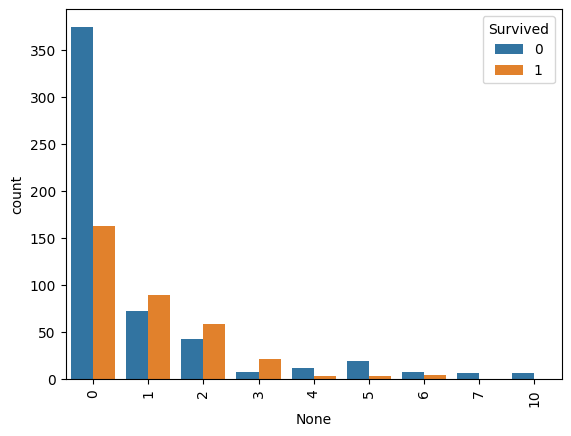

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=[20, 10])

sns.countplot(x=train_df["SibSp"] + train_df["Parch"],
              hue=train_df["Survived"])
# legend: 圖例 axis: 軸 ticks: 刻度
plt.xticks(rotation=90)